In [1]:
# ==============================================================
# FRB Isotropy Test
# LEVEL 2: mask + selection function (NO JK)
# "Observed sky vs instrument-weighted isotropy"
# ==============================================================
# ✔ Selection Function (SF)
#         S(α,δ)
# It represents:
# 1. cobertura do CHIME
# 2. sobreposição de surveys
# 3. regiões sem observação
# 4. densidade angular real de detecção
# ==============================================================

import numpy as np
import pandas as pd
import treecorr
import os
import healpy as hp
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import ks_2samp
import seaborn as sns
from astropy.coordinates import SkyCoord
import astropy.units as u

In [2]:
# ==============================================================
# 1. GENERAL CONFIGURATIONS
# ==============================================================

BASE_PATH = "/home/brunowesley/projetos/FRB-isotropy-tests/FRB_catalogs/"
ALL_FRB_PATH = os.path.join(BASE_PATH, "SkyPosition.csv")

N_RAND_FACTOR = 20
N_MOCKS = 200

# --- Mask configuration (Level 1)
GAL_CUT = 20.0  # degrees

# --- Selection Function (Level 2)
USE_SELECTION_FUNCTION = True
NSIDE_SF = 64

USE_LOG = False
MAX_SEP = 180.0
MIN_SEP = 0.1

if USE_LOG:
    BIN_TYPE = 'Log'
    N_BINS = 20
else:
    BIN_TYPE = 'Linear'
    BIN_SIZE = 1.8
    N_BINS = int((MAX_SEP - MIN_SEP) / BIN_SIZE)

COARSE_BINS = np.arange(0, 181, 20)
COARSE_CENTERS = 0.5 * (COARSE_BINS[:-1] + COARSE_BINS[1:])

In [ ]:
# ==============================================================
# 2. MASK FUNCTION + LOAD CATALOG (LEVEL 2)
# ==============================================================

def apply_mask(df):
    """
    Galactic mask: |b| > GAL_CUT
    """

    coords = SkyCoord(
        ra=df['RA'].values * u.degree,
        dec=df['DEC'].values * u.degree,
        frame='icrs'
    )

    b = coords.galactic.b.degree

    return df[np.abs(b) > GAL_CUT].reset_index(drop=True)


def load_catalog(path):
    """
    Load full catalog (RA/DEC only for stats + full sample preserved)
    """
    df = pd.read_csv(path)[["RA", "DEC"]].dropna()
    return df

In [ ]:
# ==============================================================
# 3. SELECTION FUNCTION (LEVEL 2 — single instrument)
# ==============================================================

def build_selection_function(df, nside=64):
    """
    Empirical selection function from observed sky density.

    Assumes:
    - single effective instrument
    - observed density ≈ exposure × intrinsic distribution
    """

    theta = np.radians(90 - df["DEC"].values)
    phi = np.radians(df["RA"].values)

    pix = hp.ang2pix(nside, theta, phi)

    map_sf = np.bincount(pix, minlength=hp.nside2npix(nside)).astype(float)

    # normalize → probability map
    map_sf /= np.sum(map_sf)

    # smooth a bit (optional but recommended)
    map_sf = hp.smoothing(map_sf, sigma=np.radians(5))

    # renormalize after smoothing
    map_sf /= np.sum(map_sf)

    return map_sf, nside


# ==============================================================
# 4. SELECTION FUNCTION RANDOM CATALOG
# ==============================================================

def generate_sf_catalog(n, sf_map, nside, seed=None):

    rng = np.random.default_rng(seed)

    npix = len(sf_map)

    probs = sf_map + 1e-12
    probs /= probs.sum()

    chosen_pix = rng.choice(npix, size=n, p=probs)

    theta, phi = hp.pix2ang(nside, chosen_pix)

    ra = np.degrees(phi)
    dec = 90 - np.degrees(theta)

    return pd.DataFrame({"RA": ra, "DEC": dec})

In [6]:
# ==============================================================
# 4. 2pACF (LANDY–SZALAY) 
# ==============================================================

def compute_2pacf(df_data, df_rand, log_spacing=False):

    cat_data = treecorr.Catalog(
        ra=df_data["RA"], dec=df_data["DEC"],
        ra_units="deg", dec_units="deg"
    )

    cat_rand = treecorr.Catalog(
        ra=df_rand["RA"], dec=df_rand["DEC"],
        ra_units="deg", dec_units="deg"
    )

    bin_type = 'Log' if log_spacing else 'Linear'

    corr = treecorr.NNCorrelation(
        min_sep=MIN_SEP,
        max_sep=MAX_SEP,
        nbins=N_BINS,
        sep_units="deg",
        metric='Arc',
        bin_type=bin_type
    )

    rr = treecorr.NNCorrelation(**corr.config)
    dr = treecorr.NNCorrelation(**corr.config)

    corr.process(cat_data)
    rr.process(cat_rand)
    dr.process(cat_data, cat_rand)

    corr.calculateXi(rr=rr, dr=dr)

    theta = np.exp(corr.meanlogr)

    return theta, corr.xi


# ==============================================================
# 5. ABSOLUTE SUM TEST
# ==============================================================

def get_absolute_sum(theta, w):

    vals = []

    for i in range(len(COARSE_BINS) - 1):

        mask = (theta >= COARSE_BINS[i]) & (theta < COARSE_BINS[i+1])

        if np.any(mask):
            vals.append(np.abs(np.mean(w[mask])))
        else:
            vals.append(0.0)

    return np.array(vals)


In [7]:
# ==============================================================
# 6. OBSERVATIONAL DATA (LEVEL 1)
# ==============================================================

print(f"\n--- Processing data ({BIN_TYPE}) ---")

# 1. Load + mask real data
df_data = apply_mask(load_catalog(ALL_FRB_PATH))

# 2. Build selection function from observed sky
sf_map, sf_nside = build_selection_function(df_data, nside=64)

# 3. Generate random catalog WITH selection function
df_rand = generate_sf_catalog(
    n=len(df_data) * N_RAND_FACTOR,
    sf_map=sf_map,
    nside=sf_nside,
    seed=2000
)

# 4. 2pACF
theta, w = compute_2pacf(df_data, df_rand, log_spacing=USE_LOG)

# 5. Observables
mean_w_obs = w
mean_abs_obs = get_absolute_sum(theta, w)


--- Processing data (Linear) ---


In [8]:
# ==============================================================
# 7. H0 MOCKS (LEVEL 2)
# ==============================================================

print("\n--- Generating H0 mocks (Level 2) ---")

# number of objects per mock
n_avg = len(df_data)

# build selection function ONCE (from real data)
sf_map, sf_nside = build_selection_function(df_data, nside=64)

all_w_h0 = []
all_abs_h0 = []

for i in tqdm(range(N_MOCKS)):

    # isotropic realization but projected through selection function
    d_iso = generate_sf_catalog(
        n=n_avg,
        sf_map=sf_map,
        nside=sf_nside,
        seed=i
    )

    r_iso = generate_sf_catalog(
        n=len(d_iso) * N_RAND_FACTOR,
        sf_map=sf_map,
        nside=sf_nside,
        seed=i + 5000
    )

    theta_h0, w_h0 = compute_2pacf(
        d_iso,
        r_iso,
        log_spacing=USE_LOG
    )

    all_w_h0.append(w_h0)
    all_abs_h0.append(get_absolute_sum(theta_h0, w_h0))

all_w_h0 = np.array(all_w_h0)
all_abs_h0 = np.array(all_abs_h0)

h0_mean = np.mean(all_w_h0, axis=0)
h0_std = np.std(all_w_h0, axis=0)

h0_abs_mean = np.mean(all_abs_h0, axis=0)
h0_abs_std = np.std(all_abs_h0, axis=0)


--- Generating H0 mocks (Level 2) ---


  0%|          | 0/200 [00:00<?, ?it/s]

In [9]:
# ==============================================================
# 8. STATISTICS (LEVEL 2)
# ==============================================================

print("\n--- Statistical tests (Level 2) ---")

# covariance from H0 mocks (NOW consistent with selection function)
cov = np.cov(all_w_h0, rowvar=False)
inv_cov = np.linalg.pinv(cov)

# chi-square test
delta = mean_w_obs - h0_mean

chi2 = delta @ inv_cov @ delta
dof = len(delta)

print(f"Chi2/dof = {chi2/dof:.2f}")

# KS test on absolute statistic
ks_stat, ks_p = ks_2samp(mean_abs_obs, h0_abs_mean)

print(f"KS p-value = {ks_p:.4e}")


--- Statistical tests (Level 2) ---
Chi2/dof = 43.32
KS p-value = 3.5171e-01


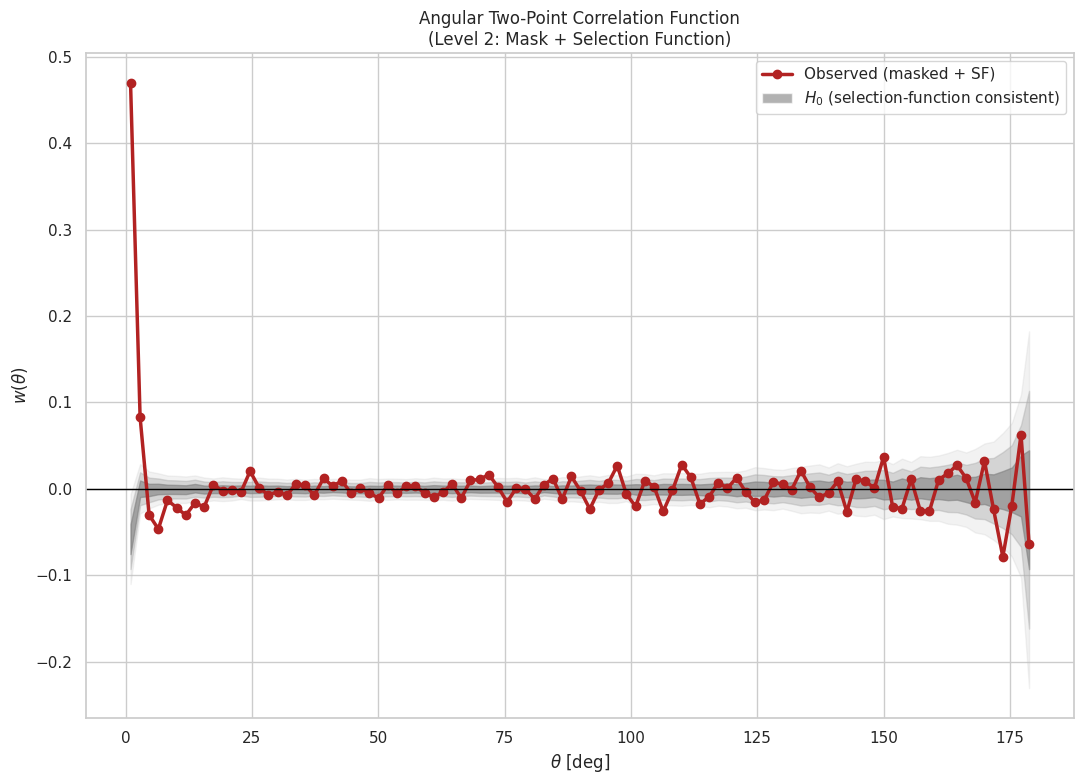

In [10]:
# ==============================================================
# 9. PLOT — 2pACF
# ==============================================================

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 8))

# H0 bands (Level 2: selection-function-consistent)
ax.fill_between(theta, h0_mean - 3*h0_std, h0_mean + 3*h0_std,
                color='silver', alpha=0.2)
ax.fill_between(theta, h0_mean - 2*h0_std, h0_mean + 2*h0_std,
                color='darkgray', alpha=0.4)
ax.fill_between(theta, h0_mean - h0_std, h0_mean + h0_std,
                color='gray', alpha=0.6)

# Observed signal (no extra errors here in Level 2 baseline plot)
ax.plot(theta, mean_w_obs, 'o-', color='firebrick',
        lw=2.5, label='Observed (masked + SF)')

ax.axhline(0, color='black', linewidth=1)

ax.set_xlabel(r'$\theta$ [deg]')
ax.set_ylabel(r'$w(\theta)$')

ax.set_title('Angular Two-Point Correlation Function\n(Level 2: Mask + Selection Function)')

h0_patch = Patch(facecolor='gray', alpha=0.6,
                 label=r'$H_0$ (1σ, 2σ, 3σ)')

handles, labels = ax.get_legend_handles_labels()
handles.append(h0_patch)
labels.append(r'$H_0$ (selection-function consistent)')

ax.legend(handles, labels)

plt.tight_layout()
plt.savefig("FRB_2PACF_level2.png", dpi=300)
plt.show()

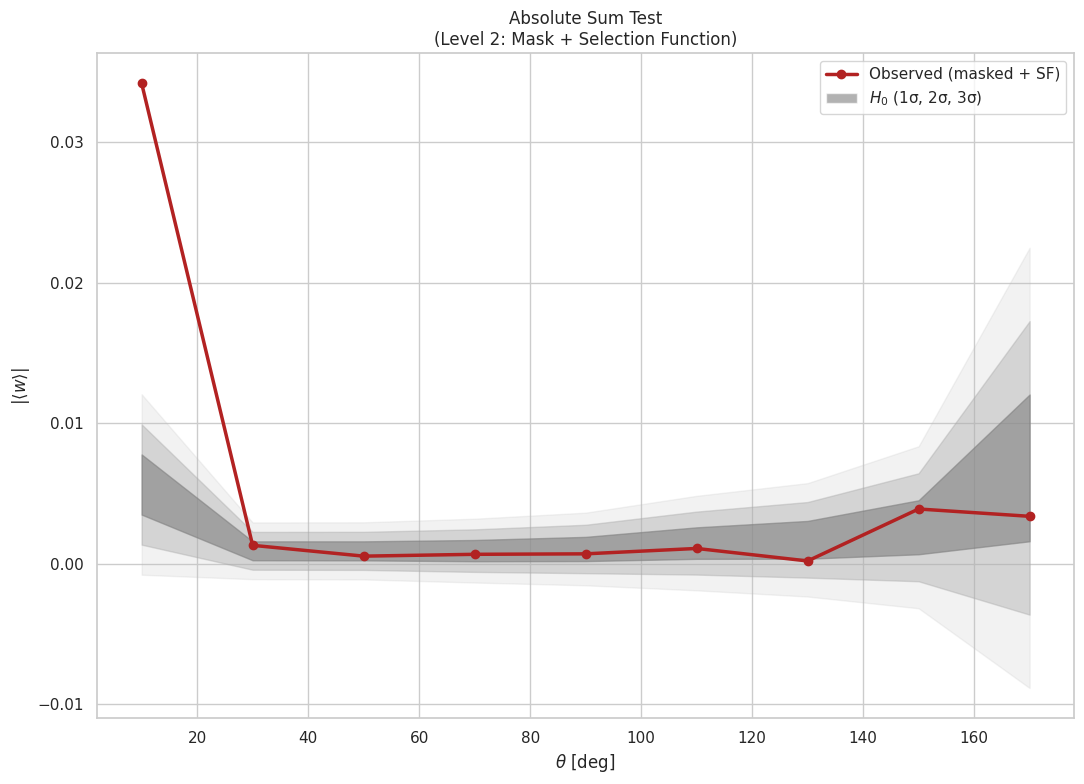

In [11]:
# ==============================================================
# 10. PLOT — ABSOLUTE SUM
# ==============================================================

fig, ax = plt.subplots(figsize=(11, 8))

# H0 bands (Level 2)
ax.fill_between(COARSE_CENTERS,
                h0_abs_mean - 3*h0_abs_std,
                h0_abs_mean + 3*h0_abs_std,
                color='silver', alpha=0.2)

ax.fill_between(COARSE_CENTERS,
                h0_abs_mean - 2*h0_abs_std,
                h0_abs_mean + 2*h0_abs_std,
                color='darkgray', alpha=0.4)

ax.fill_between(COARSE_CENTERS,
                h0_abs_mean - h0_abs_std,
                h0_abs_mean + h0_abs_std,
                color='gray', alpha=0.6)

# Observed
ax.plot(COARSE_CENTERS, mean_abs_obs,
        'o-', color='firebrick',
        lw=2.5, label='Observed (masked + SF)')

ax.set_xlabel(r'$\theta$ [deg]')
ax.set_ylabel(r'$|\langle w \rangle|$')

ax.set_title('Absolute Sum Test\n(Level 2: Mask + Selection Function)')

h0_patch = Patch(facecolor='gray', alpha=0.6,
                 label=r'$H_0$ (selection-function consistent)')

handles, labels = ax.get_legend_handles_labels()
handles.append(h0_patch)
labels.append(r'$H_0$ (1σ, 2σ, 3σ)')

ax.legend(handles, labels)

plt.tight_layout()
plt.savefig("FRB_ABS_level2.png", dpi=300)
plt.show()